### EDA for Student performance

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv("data/data.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [32]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [22]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [23]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [24]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [35]:
obj_columns = df.select_dtypes(include=['object']).columns

for col in obj_columns:
    if isinstance(col, object):
        print(f"Unique values in {col} : {set(df[col])}")

Unique values in gender : {'male', 'female'}
Unique values in race_ethnicity : {'group C', 'group D', 'group B', 'group A', 'group E'}
Unique values in parental_level_of_education : {'some college', 'some high school', 'high school', "master's degree", "associate's degree", "bachelor's degree"}
Unique values in lunch : {'free/reduced', 'standard'}
Unique values in test_preparation_course : {'completed', 'none'}


#### Convert the categorical features into number

In [36]:
from sklearn.preprocessing import LabelEncoder

df_og = df.copy()

columns = df.select_dtypes(include=['object']).columns

for col in columns:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col])

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,gender_encoded,race_ethnicity_encoded,parental_level_of_education_encoded,lunch_encoded,test_preparation_course_encoded
0,female,group B,bachelor's degree,standard,none,72,72,74,0,1,1,1,1
1,female,group C,some college,standard,completed,69,90,88,0,2,4,1,0
2,female,group B,master's degree,standard,none,90,95,93,0,1,3,1,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,1,0,0,0,1
4,male,group C,some college,standard,none,76,78,75,1,2,4,1,1


In [37]:
df_og.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [38]:
columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='object')

In [39]:
df.drop(columns, axis=1, inplace=True)

#### Add feature Total score and Average score

In [47]:
df["total_score"] = df['math_score'] + df['reading_score'] + df['writing_score']

df["average_score"] = df["total_score"] / 3

df.head()

,math_score,reading_score,writing_score,gender_encoded,race_ethnicity_encoded,parental_level_of_education_encoded,lunch_encoded,test_preparation_course_encoded,total_score,average_score
0,72,72,74,0,1,1,1,1,218,72.666667
1,69,90,88,0,2,4,1,0,247,82.333333
2,90,95,93,0,1,3,1,1,278,92.666667
3,47,57,44,1,0,0,0,1,148,49.333333
4,76,78,75,1,2,4,1,1,229,76.333333


#### Histogram for Average Score

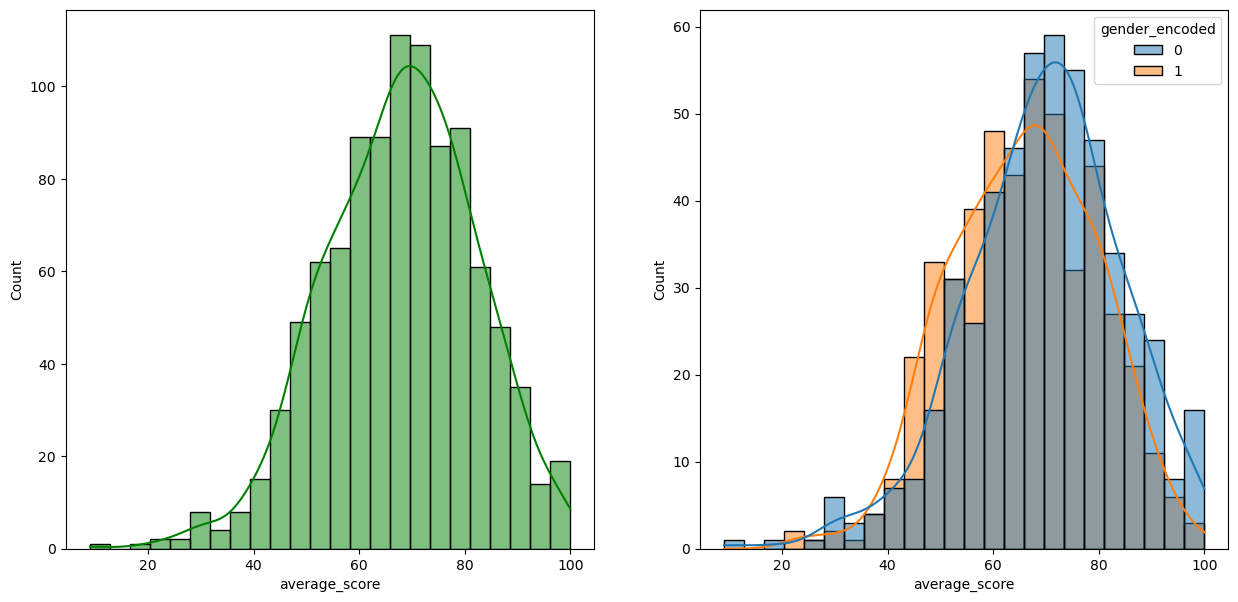

In [42]:
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='average_score', kde=True, color='g')
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='average_score', kde=True, hue='gender_encoded')
plt.show()

In [43]:
obj_columns_encoded = ['gender_encoded',
       'race_ethnicity_encoded', 'parental_level_of_education_encoded',
       'lunch_encoded', 'test_preparation_course_encoded']

obj_columns_encoded

['gender_encoded',
 'race_ethnicity_encoded',
 'parental_level_of_education_encoded',
 'lunch_encoded',
 'test_preparation_course_encoded']

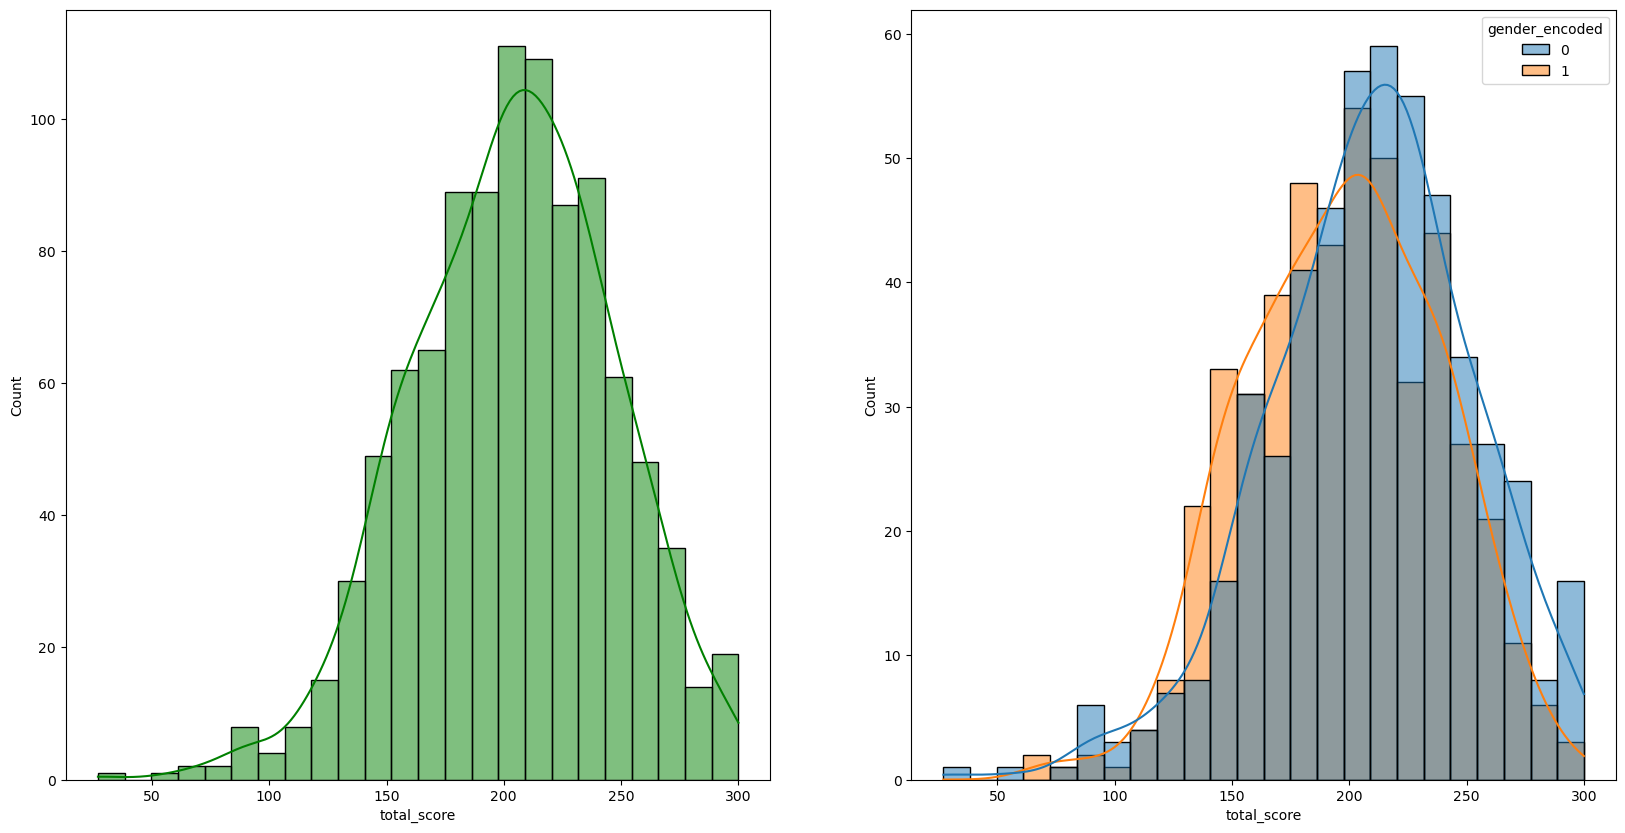

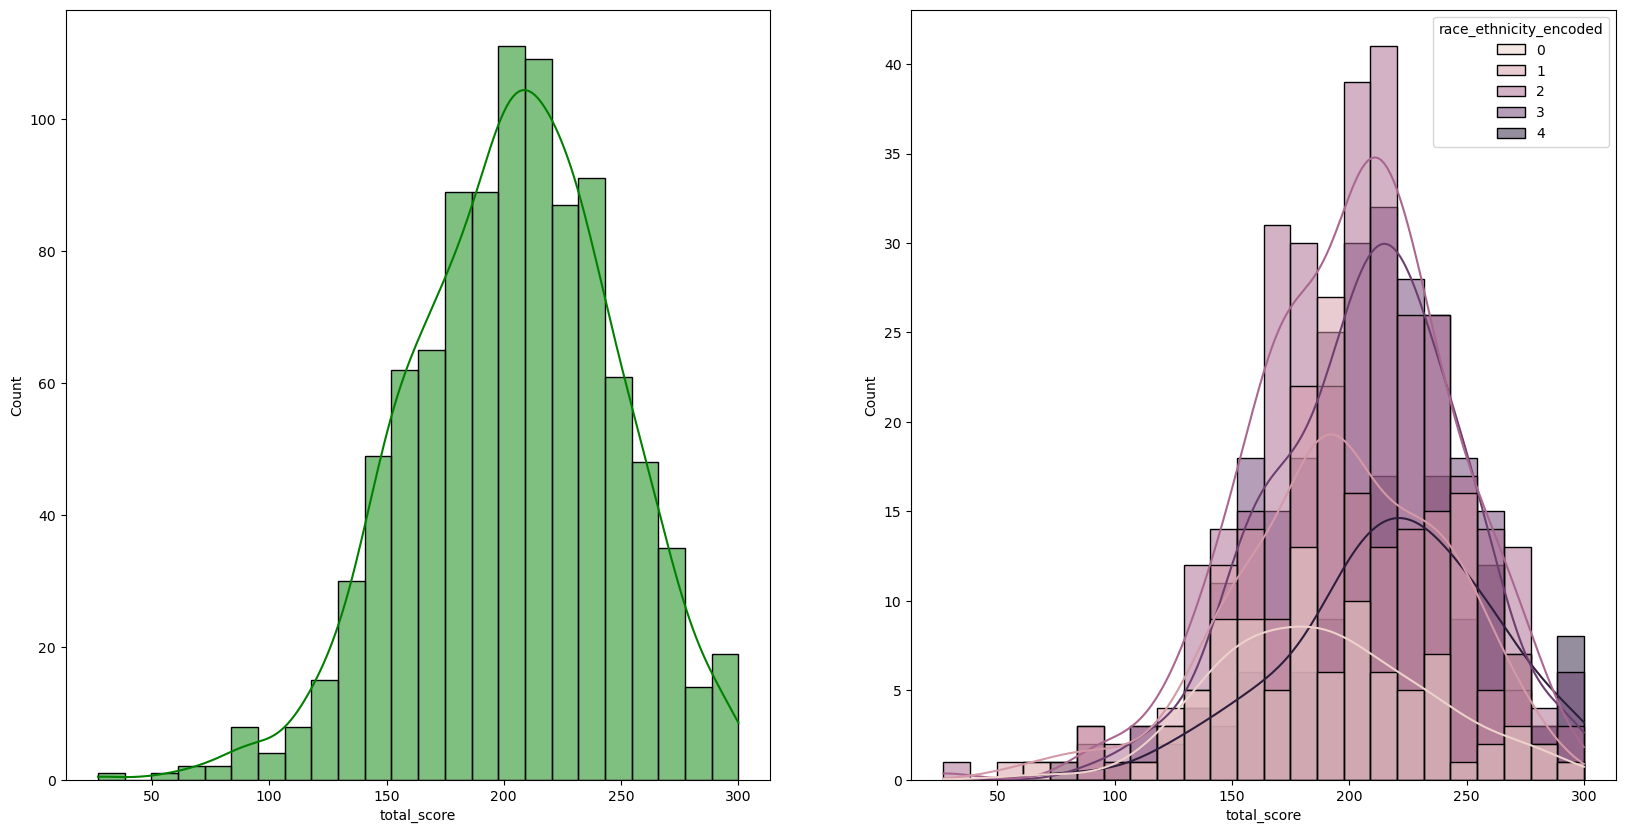

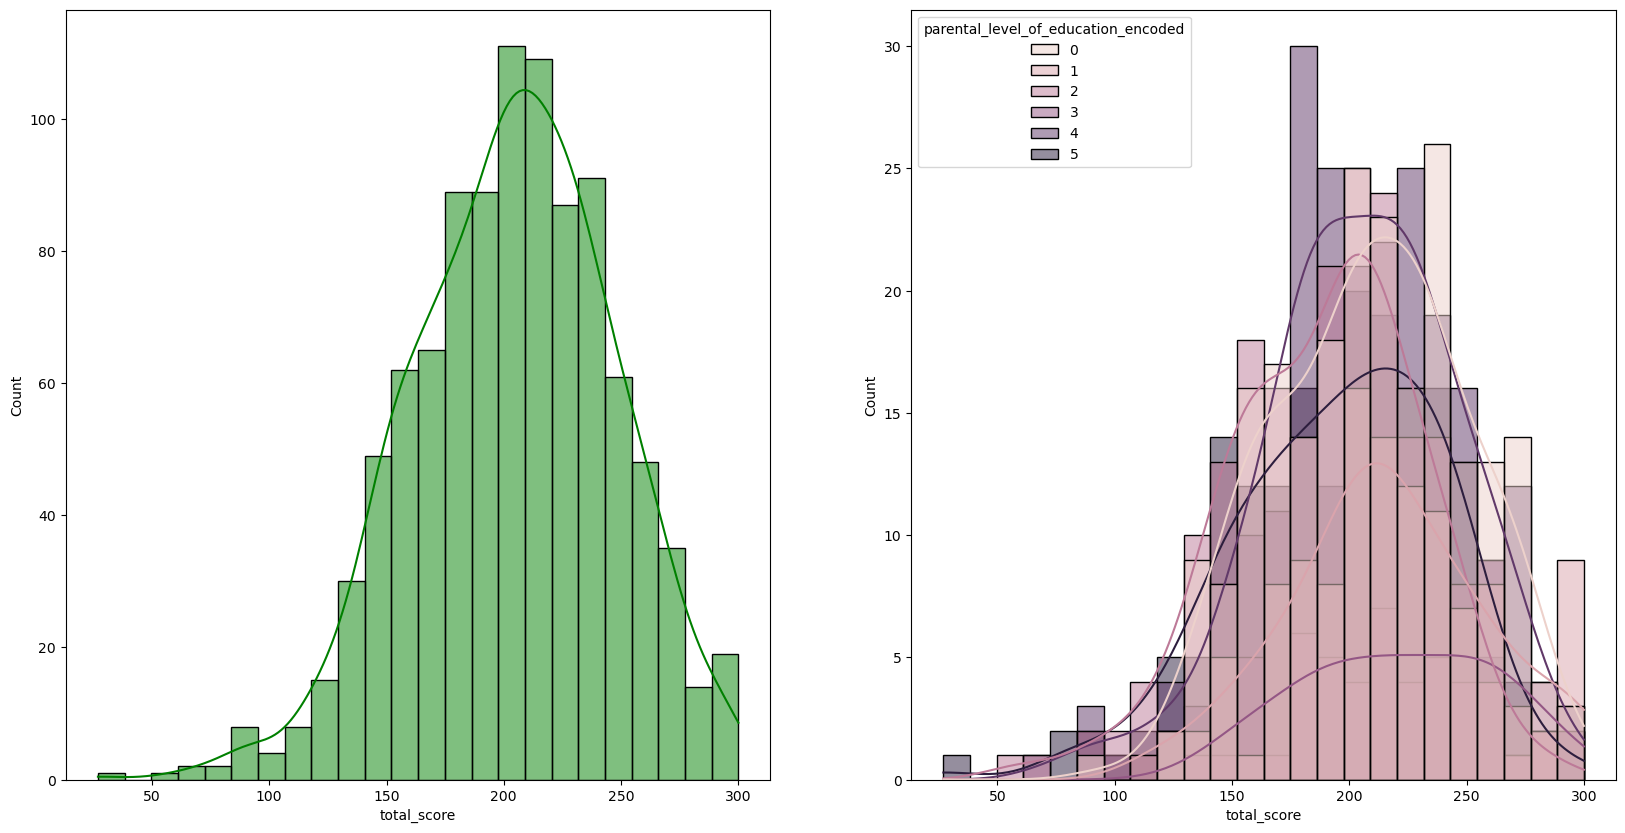

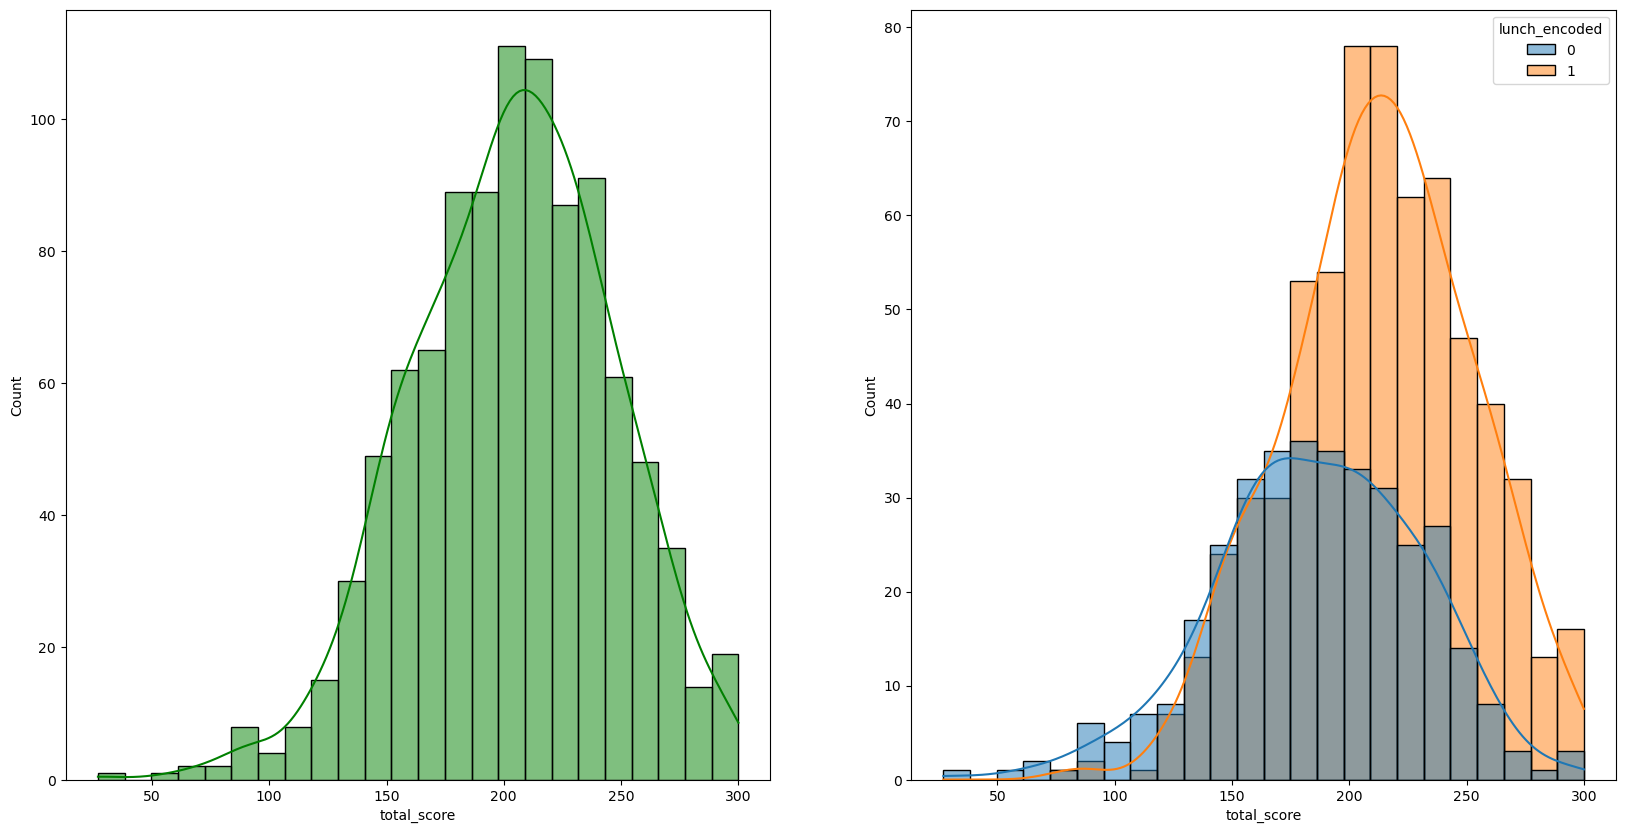

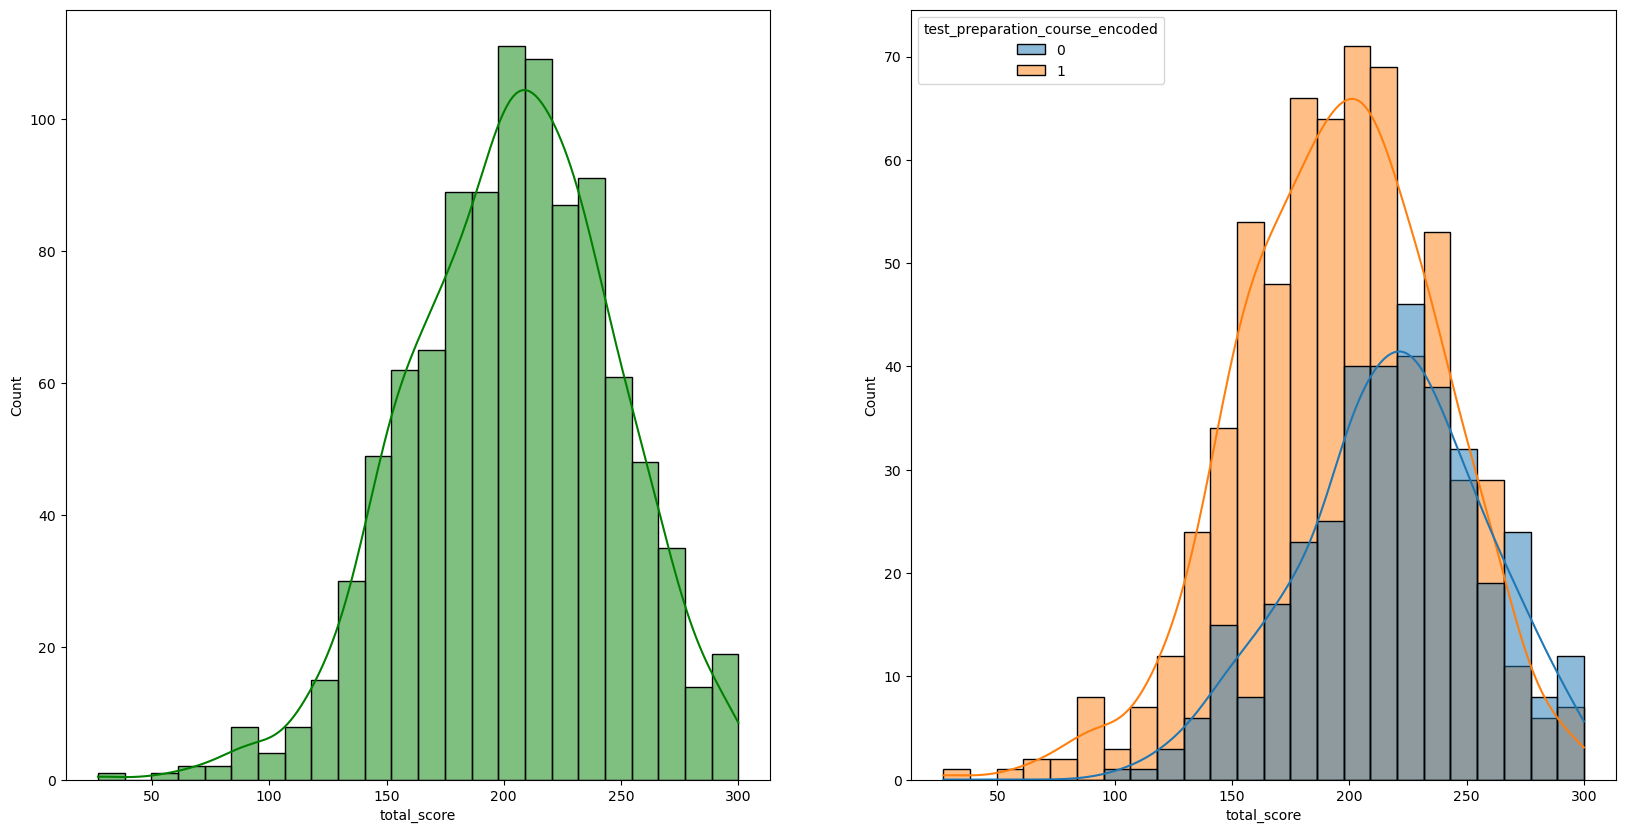

In [44]:
for col in obj_columns_encoded:
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x='total_score', kde=True, color='g')
    plt.subplot(1, 2, 2)
    sns.histplot(data=df, x='total_score', kde=True, hue=col)
    plt.show()

In [46]:
df_og.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


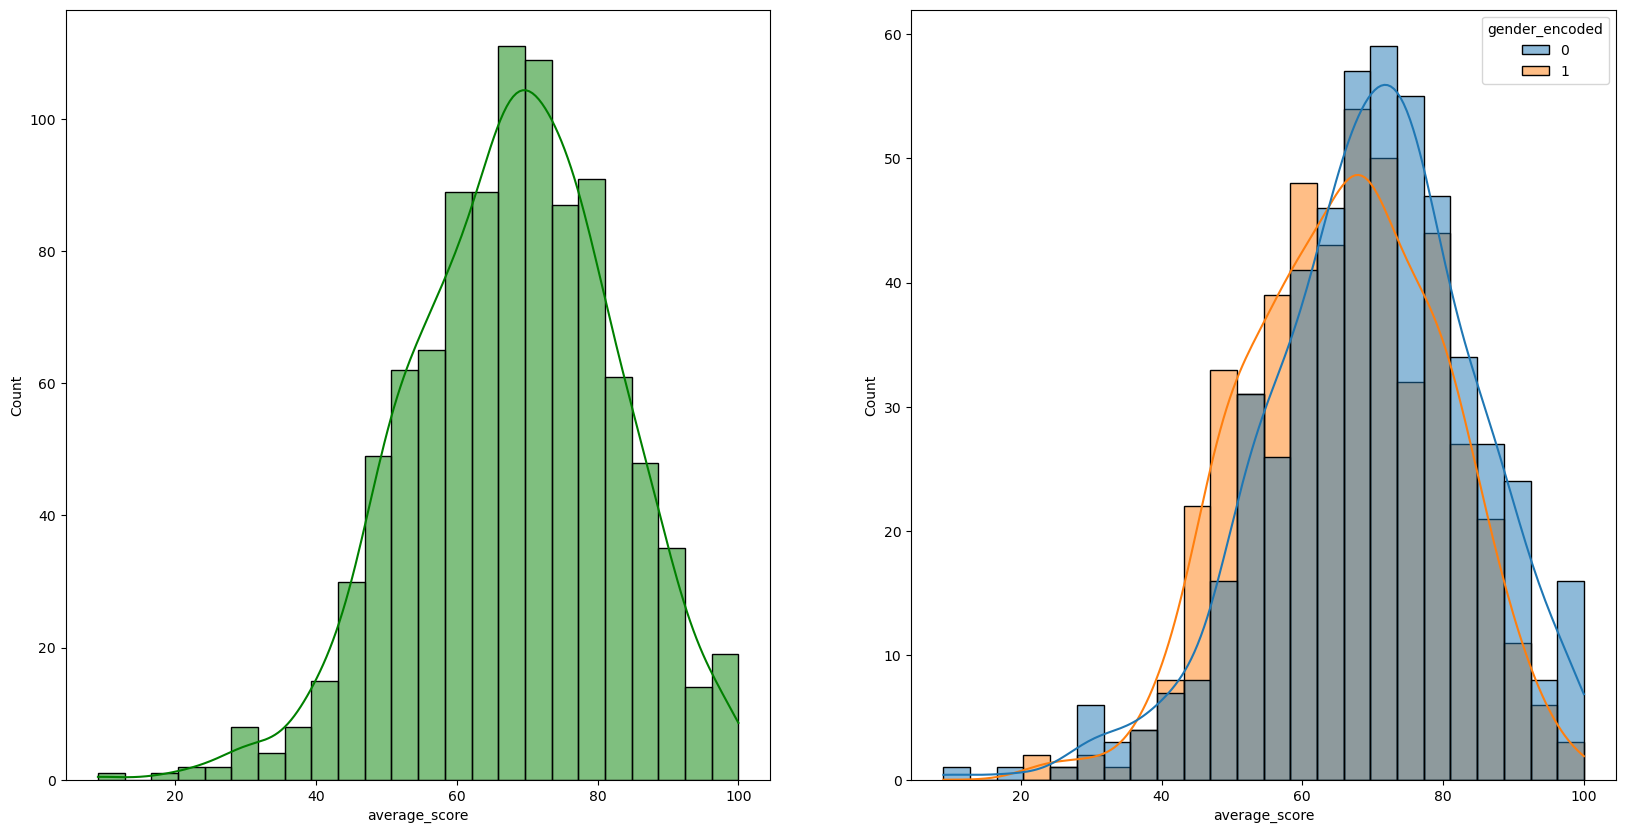

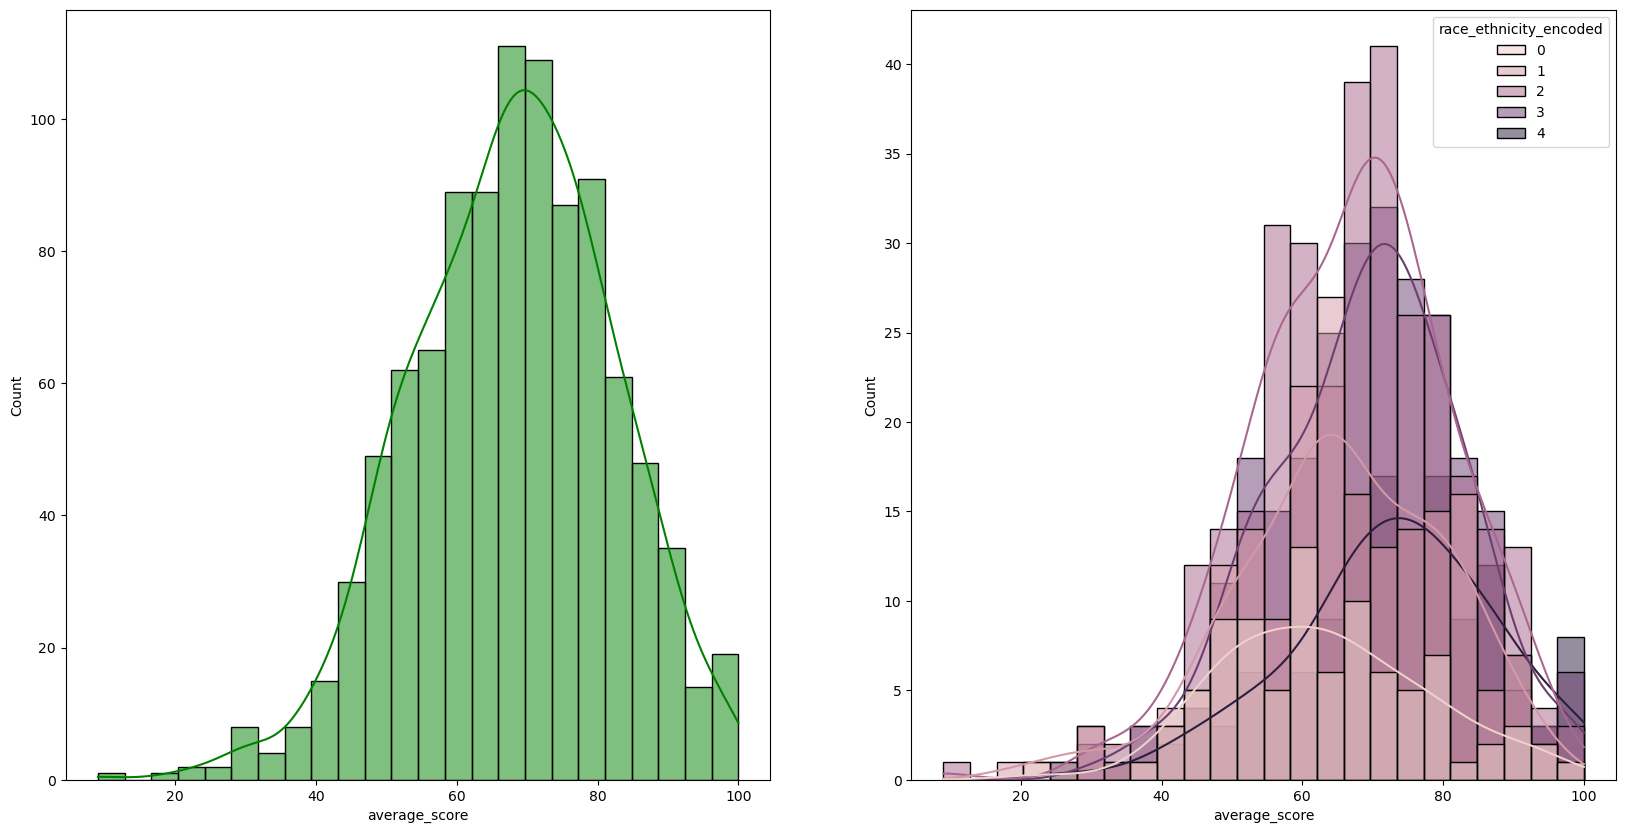

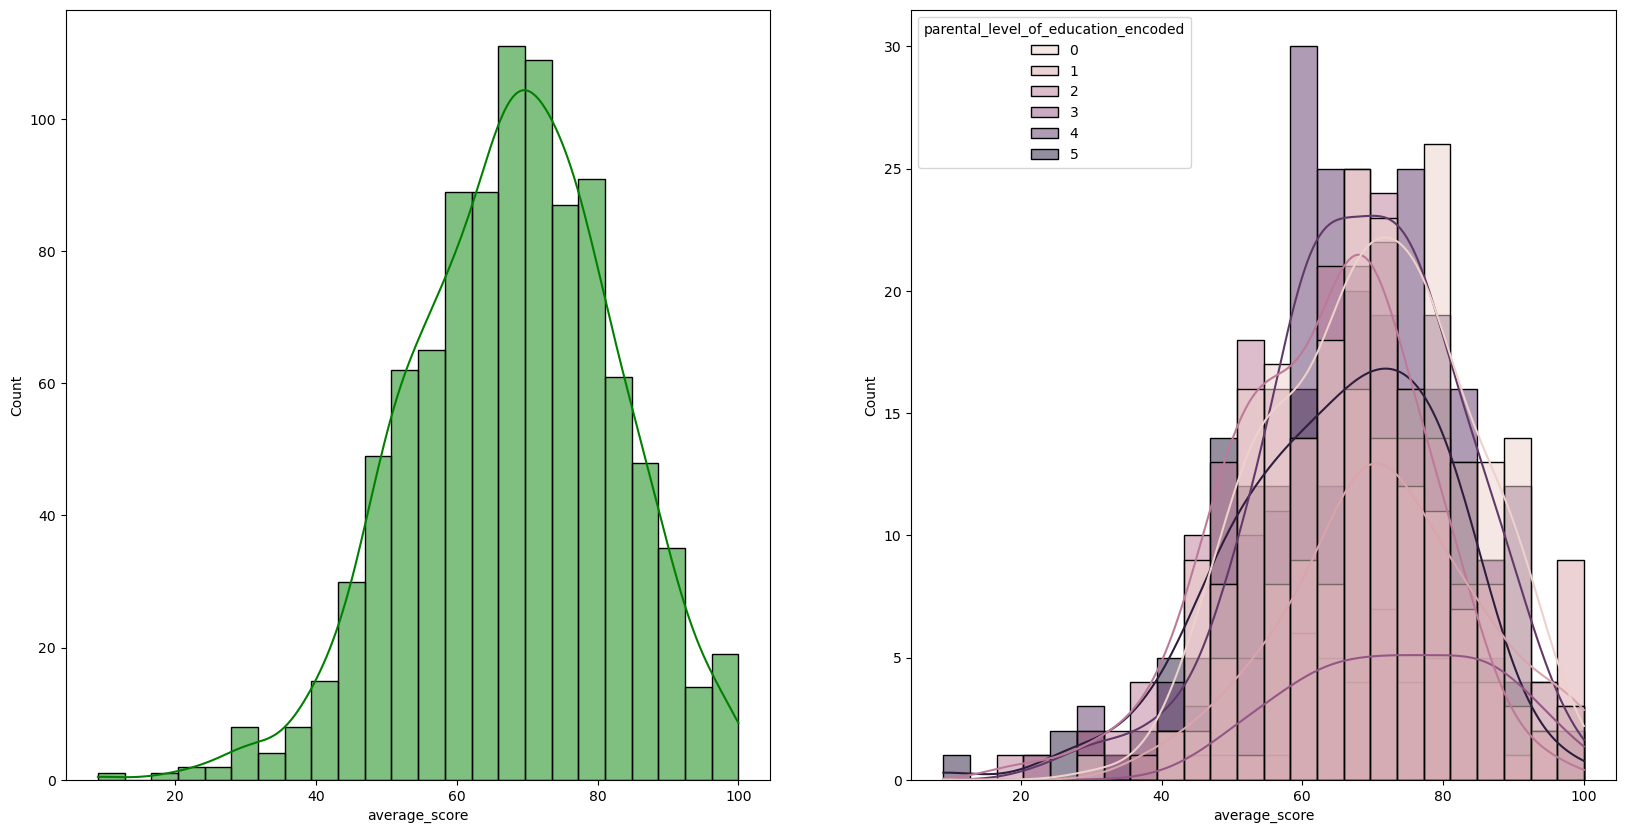

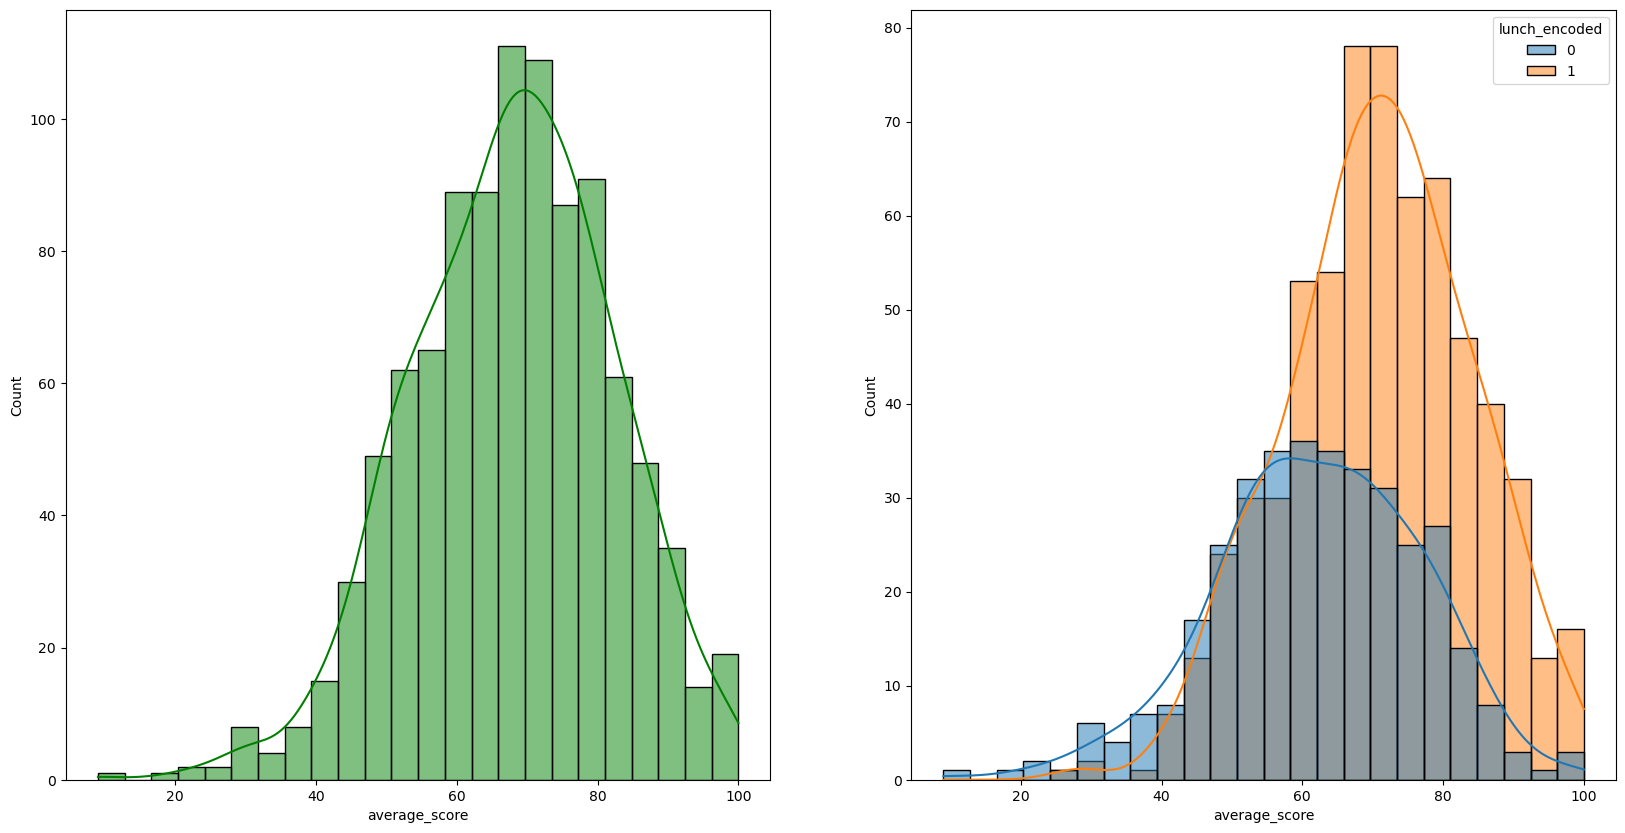

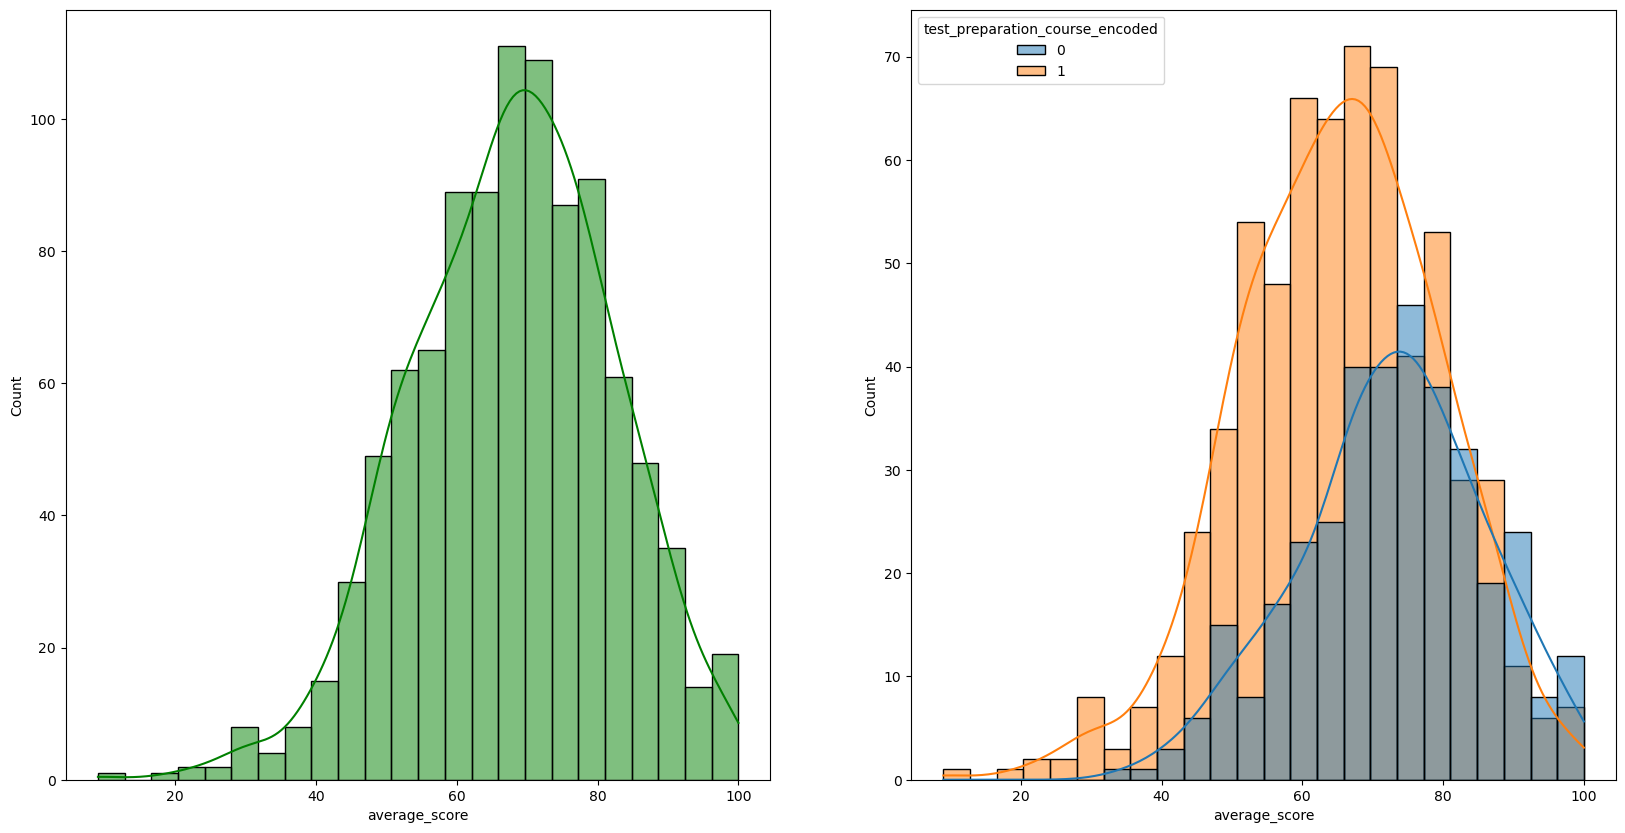

In [ ]:
for col in obj_columns_encoded:
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x='average_score', kde=True, color='g')
    plt.subplot(1, 2, 2)
    sns.histplot(data=df, x='average_score', kde=True, hue=col)
    plt.show()

np.int64(7)

In [65]:
print(f"Number of students with full marks in math: {df[df['math_score'] == 100]['average_score'].count()}")

print(f"Number of students with full marks in reading: {df[df['reading_score'] == 100]['average_score'].count()}")

print(f"Number of students with full marks in writing: {df[df['writing_score'] == 100]['average_score'].count()}")

Number of students with full marks in math: 7
Number of students with full marks in reading: 17
Number of students with full marks in writing: 14
